# 60 Multi-Model Comparison

Aggregates baseline and LoRA metrics across models and plots comparison charts.


In [1]:
# Cell 0: Load metrics and setup shared paths.
from pathlib import Path
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve project root robustly from notebook execution location.
# Typical run location is PROJECT_ROOT/notebooks, so this maps to parent.
def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()

    # Common case: running from project_root/notebooks
    if cwd.name == 'notebooks' and (cwd.parent / 'express-emotion-recognition').exists():
        return cwd.parent

    # If already at project root
    if (cwd / 'express-emotion-recognition').exists() and (cwd / 'outputs').exists():
        return cwd

    # Walk upward to find the first directory containing required folders.
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'express-emotion-recognition').exists() and (candidate / 'outputs').exists():
            return candidate

    raise FileNotFoundError(
        f'Could not resolve project root from cwd={cwd}. '
        'Expected to find express-emotion-recognition and outputs directories.'
    )

PROJECT_ROOT = resolve_project_root()
EXPRESS_ROOT = PROJECT_ROOT / 'express-emotion-recognition'
METRICS_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'all_models_metrics.csv'
FIGURE_OUT = PROJECT_ROOT / 'outputs' / 'figures' / 'figure2_baseline_plus_lora_overlay.png'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('EXPRESS_ROOT =', EXPRESS_ROOT)

if METRICS_PATH.exists():
    lora_df = pd.read_csv(METRICS_PATH)
    print('Loaded LoRA metrics rows:', len(lora_df))
    display(lora_df[['model_id', 'family', 'size_b', 'accv', 'clean_output_path']].tail(20))
else:
    lora_df = pd.DataFrame()
    print('Missing', METRICS_PATH)


PROJECT_ROOT = /home/rameyjm7/workspace/masked-emotion-lora-benchmark
EXPRESS_ROOT = /home/rameyjm7/workspace/masked-emotion-lora-benchmark/express-emotion-recognition
Loaded LoRA metrics rows: 39


,model_id,family,size_b,accv,clean_output_path
19,roberta_large_large_full_qkv_dense_seed1337,roberta,0.355,0.581710,/home/rameyjm7/workspace/masked-emotion-lora-b...
20,roberta_large_large_full_qkv_dense_rank48_lr1e5,roberta,0.355,0.586255,/home/rameyjm7/workspace/masked-emotion-lora-b...
21,roberta_large_57c_full_qkv_dense_ref,roberta,0.355,0.581602,/home/rameyjm7/workspace/masked-emotion-lora-b...
22,roberta_large_57c_full_qkv_dense_rank48,roberta,0.355,0.585804,/home/rameyjm7/workspace/masked-emotion-lora-b...
23,roberta_large_57c_full_qkv_dense_rank64_lowdrop,roberta,0.355,0.587843,/home/rameyjm7/workspace/masked-emotion-lora-b...
24,roberta_large_57c_full_qkv_dense_rank64_seed1337,roberta,0.355,0.587392,/home/rameyjm7/workspace/masked-emotion-lora-b...
25,roberta_large_57c_final_full_rank64_conservative,roberta,0.355,0.585408,/home/rameyjm7/workspace/masked-emotion-lora-b...
26,roberta_base_ppo_12k_qkv,roberta,0.125,0.466595,/home/rameyjm7/workspace/masked-emotion-lora-b...
27,roberta_large_57c_ensemble_top2,roberta,0.355,0.588113,/home/rameyjm7/workspace/masked-emotion-lora-b...
28,roberta_large_57c_final_full_rank64_noval_cano...,roberta,0.355,0.594715,/home/rameyjm7/workspace/masked-emotion-lora-b...


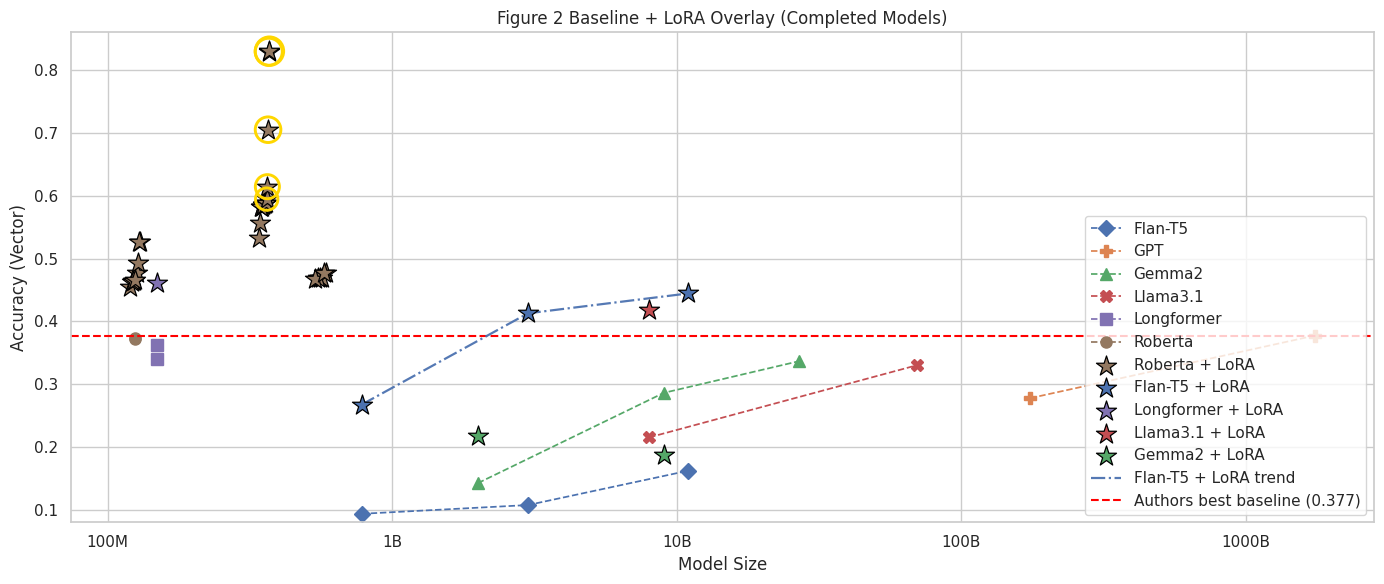

Saved figure: /home/rameyjm7/workspace/masked-emotion-lora-benchmark/outputs/figures/figure2_baseline_plus_lora_overlay.png


,model_id,base_label,plot_family,size_b,base_accv,accv,delta_accv
38,roberta_large_59_continue_from_57c_final_e4_lr...,NaN,Roberta,0.355,NaN,0.830411,NaN
37,roberta_large_59_continue_from_57c_final_e4_lr...,NaN,Roberta,0.355,NaN,0.829473,NaN
35,roberta_large_59_continue_from_57c_final_e4_lr...,NaN,Roberta,0.355,NaN,0.705303,NaN
36,roberta_large_59_continue_from_57c_final_e4_lr4e6,NaN,Roberta,0.355,NaN,0.614556,NaN
28,roberta_large_57c_final_full_rank64_noval_cano...,NaN,Roberta,0.355,NaN,0.594715,NaN
27,roberta_large_57c_ensemble_top2,NaN,Roberta,0.355,NaN,0.588113,NaN
23,roberta_large_57c_full_qkv_dense_rank64_lowdrop,NaN,Roberta,0.355,NaN,0.587843,NaN
24,roberta_large_57c_full_qkv_dense_rank64_seed1337,NaN,Roberta,0.355,NaN,0.587392,NaN
20,roberta_large_large_full_qkv_dense_rank48_lr1e5,NaN,Roberta,0.355,NaN,0.586255,NaN
22,roberta_large_57c_full_qkv_dense_rank48,NaN,Roberta,0.355,NaN,0.585804,NaN


RoBERTa-focused leaderboard (same-size cluster friendly):


,model_id,size_b,accv,delta_accv
38,roberta_large_59_continue_from_57c_final_e4_lr...,0.355,0.830411,NaN
37,roberta_large_59_continue_from_57c_final_e4_lr...,0.355,0.829473,NaN
35,roberta_large_59_continue_from_57c_final_e4_lr...,0.355,0.705303,NaN
36,roberta_large_59_continue_from_57c_final_e4_lr4e6,0.355,0.614556,NaN
28,roberta_large_57c_final_full_rank64_noval_cano...,0.355,0.594715,NaN
27,roberta_large_57c_ensemble_top2,0.355,0.588113,NaN
23,roberta_large_57c_full_qkv_dense_rank64_lowdrop,0.355,0.587843,NaN
24,roberta_large_57c_full_qkv_dense_rank64_seed1337,0.355,0.587392,NaN
20,roberta_large_large_full_qkv_dense_rank48_lr1e5,0.355,0.586255,NaN
22,roberta_large_57c_full_qkv_dense_rank48,0.355,0.585804,NaN


In [2]:
# Cell 1: Reproduce Figure-2-style baseline and overlay available LoRA results.
import numpy as np
lex_df = pd.read_csv(EXPRESS_ROOT / 'data' / 'lexicon-decomposition.csv')
vec_map = {str(r['word']).lower(): tuple(int(v) for v in r.iloc[1:].tolist()) for _, r in lex_df.iterrows()}
zero_vec = tuple([0] * 10)

_parse_cache = {}
def parse_list_cached(raw):
    if isinstance(raw, list):
        return [str(x).strip().lower() for x in raw]
    if not isinstance(raw, str):
        return None
    s = raw.strip()
    if s == 'INVALID OUTPUT':
        return None
    if s in _parse_cache:
        return _parse_cache[s]
    try:
        v = ast.literal_eval(s)
        parsed = [str(x).strip().lower() for x in v] if isinstance(v, list) else None
    except Exception:
        parsed = None
    _parse_cache[s] = parsed
    return parsed


def compute_accv(csv_path):
    df = pd.read_csv(csv_path, usecols=['labels', 'output_formatted', 'number_of_labels'])
    total_masks = int(df['number_of_labels'].sum())
    matches = 0
    for raw_labels, raw_preds in zip(df['labels'].tolist(), df['output_formatted'].tolist()):
        labels = parse_list_cached(raw_labels)
        preds = parse_list_cached(raw_preds)
        if labels is None or preds is None:
            continue
        for t, p in zip(labels, preds):
            matches += int(vec_map.get(t, zero_vec) == vec_map.get(p, zero_vec))
    return (matches / total_masks) if total_masks > 0 else float('nan')

baseline_models = [
    {'model_id': 'flan_t5_large', 'label': 'Flan-T5-large', 'family': 'Flan-T5', 'size_b': 0.78, 'file': 'flan_t5_large.csv'},
    {'model_id': 'flan_t5_xl', 'label': 'Flan-T5-xl', 'family': 'Flan-T5', 'size_b': 3.0, 'file': 'flan_t5_xl.csv'},
    {'model_id': 'flan_t5_xxl', 'label': 'Flan-T5-xxl', 'family': 'Flan-T5', 'size_b': 11.0, 'file': 'flan_t5_xxl.csv'},
    {'model_id': 'gpt_35_turbo', 'label': 'Gpt-3.5-turbo', 'family': 'GPT', 'size_b': 175.0, 'file': 'gpt_35_turbo_0125.csv'},
    {'model_id': 'gpt_4o', 'label': 'Gpt-4o', 'family': 'GPT', 'size_b': 1750.0, 'file': 'gpt_4o.csv'},
    {'model_id': 'gemma2_2b_it', 'label': 'Gemma-2-2B-it', 'family': 'Gemma2', 'size_b': 2.0, 'file': 'gemma2_2B_it.csv'},
    {'model_id': 'gemma2_9b_it', 'label': 'Gemma-2-9B-it', 'family': 'Gemma2', 'size_b': 9.0, 'file': 'gemma2_9B_it.csv'},
    {'model_id': 'gemma2_27b_it', 'label': 'Gemma-2-27B-it', 'family': 'Gemma2', 'size_b': 27.0, 'file': 'gemma2_27B_it.csv'},
    {'model_id': 'llama31_8b_instruct', 'label': 'Llama3.1-8B-instruct', 'family': 'Llama3.1', 'size_b': 8.0, 'file': 'llama3.1_8B_instruct.csv'},
    {'model_id': 'llama31_70b_instruct', 'label': 'Llama3.1-70B-instruct', 'family': 'Llama3.1', 'size_b': 70.0, 'file': 'llama3.1_70B_instruct.csv'},
    {'model_id': 'longformer_base', 'label': 'Longformer-base', 'family': 'Longformer', 'size_b': 0.149, 'file': 'longformer.csv'},
    {'model_id': 'mental_longformer_base', 'label': 'Mental-Longformer-base', 'family': 'Longformer', 'size_b': 0.149, 'file': 'mental-longformer.csv'},
    {'model_id': 'roberta_base', 'label': 'Roberta-base', 'family': 'Roberta', 'size_b': 0.125, 'file': 'roberta-base.csv'},
    {'model_id': 'mental_roberta_base', 'label': 'Mental-Roberta-base', 'family': 'Roberta', 'size_b': 0.125, 'file': 'mental-roberta-base.csv'},
]

base_rows = []
for m in baseline_models:
    csv_path = EXPRESS_ROOT / 'results' / m['file']
    base_rows.append({**m, 'accv': compute_accv(csv_path)})
base_df = pd.DataFrame(base_rows)


def normalize_model_id(x):
    return str(x).strip().lower().replace('-', '_').replace('.', '_')


def infer_family(model_id_norm, fallback=None):
    if isinstance(fallback, str) and fallback:
        return fallback
    if 'roberta' in model_id_norm:
        return 'Roberta'
    if 'flan' in model_id_norm:
        return 'Flan-T5'
    if 'gemma' in model_id_norm:
        return 'Gemma2'
    if 'llama' in model_id_norm:
        return 'Llama3.1'
    if 'longformer' in model_id_norm:
        return 'Longformer'
    if 'gpt' in model_id_norm:
        return 'GPT'
    return 'Roberta'


if not lora_df.empty:
    lo = lora_df.copy()
    lo['model_id_norm'] = lo['model_id'].map(normalize_model_id)
    lo['accv'] = pd.to_numeric(lo['accv'], errors='coerce')
    lo['size_b'] = pd.to_numeric(lo['size_b'], errors='coerce')
    lo = lo.dropna(subset=['accv', 'size_b'])

    if 'timestamp_utc' in lo.columns:
        lo = lo.sort_values('timestamp_utc').groupby('model_id_norm', as_index=False).tail(1)

    base_map = {normalize_model_id(x): x for x in base_df['model_id'].tolist()}
    lo['base_model_id'] = lo['model_id_norm'].map(lambda x: base_map.get(x, x))

    lora_plot = lo[['model_id', 'model_id_norm', 'base_model_id', 'size_b', 'accv']].copy()
else:
    lora_plot = pd.DataFrame(columns=['model_id', 'model_id_norm', 'base_model_id', 'size_b', 'accv'])

lora_plot = lora_plot.merge(
    base_df[['model_id', 'label', 'family', 'accv']].rename(columns={'model_id': 'base_model_id', 'label': 'base_label', 'accv': 'base_accv'}),
    on='base_model_id',
    how='left'
)
lora_plot['plot_family'] = [infer_family(mid, fam) for mid, fam in zip(lora_plot['model_id_norm'], lora_plot['family'])]
lora_plot['delta_accv'] = lora_plot['accv'] - lora_plot['base_accv']

# Apply gentle multiplicative jitter only when same-family runs share identical model size.
lora_plot['plot_size_b'] = lora_plot['size_b'].astype(float)
if not lora_plot.empty:
    for (_, size_b), grp in lora_plot.groupby(['plot_family', 'size_b'], sort=False):
        if len(grp) <= 1:
            continue
        offsets = np.linspace(-0.018, 0.018, len(grp))
        grp_idx_sorted = grp.sort_values('accv').index.tolist()
        for off, idx in zip(offsets, grp_idx_sorted):
            lora_plot.at[idx, 'plot_size_b'] = float(size_b) * (10.0 ** float(off))

sns.set_theme(style='whitegrid')
family_colors = {
    'Flan-T5': '#4C72B0',
    'GPT': '#DD8452',
    'Gemma2': '#55A868',
    'Llama3.1': '#C44E52',
    'Longformer': '#8172B2',
    'Roberta': '#937860',
}
family_markers = {
    'Flan-T5': 'D',
    'GPT': 'P',
    'Gemma2': '^',
    'Llama3.1': 'X',
    'Longformer': 's',
    'Roberta': 'o',
}

fig, ax = plt.subplots(figsize=(14, 6))
for fam in ['Flan-T5', 'GPT', 'Gemma2', 'Llama3.1', 'Longformer', 'Roberta']:
    sub = base_df[base_df['family'] == fam].sort_values('size_b')
    if sub.empty:
        continue
    ax.plot(
        sub['size_b'], sub['accv'],
        marker=family_markers[fam],
        color=family_colors[fam],
        linestyle='--',
        linewidth=1.25,
        markersize=8,
        label=fam,
    )

if not lora_plot.empty:
    shown = set()
    for r in lora_plot.itertuples(index=False):
        fam = r.plot_family
        color = family_colors.get(fam, 'black')
        legend_label = f'{fam} + LoRA' if fam not in shown else None
        shown.add(fam)
        ax.scatter(
            [float(r.plot_size_b)], [float(r.accv)],
            marker='*', s=230, color=color, edgecolors='black', linewidths=0.9,
            label=legend_label,
            zorder=5,
        )

    # Connect Flan LoRA points similar to baseline family trends.
    flan_lora = lora_plot[lora_plot['plot_family'] == 'Flan-T5'].sort_values('size_b')
    if len(flan_lora) >= 2:
        ax.plot(
            flan_lora['size_b'], flan_lora['accv'],
            color=family_colors['Flan-T5'],
            linestyle='-.',
            linewidth=1.6,
            alpha=0.95,
            label='Flan-T5 + LoRA trend',
            zorder=4,
        )

    # Highlight best RoBERTa-like runs (mostly same-size cluster) with halo rings.
    roberta_focus = lora_plot[
        lora_plot['model_id_norm'].str.contains('roberta', na=False)
        | (lora_plot['plot_family'] == 'Roberta')
    ].sort_values('accv', ascending=False)
    top_k = roberta_focus.head(min(5, len(roberta_focus)))
    ring_sizes = np.linspace(420, 260, len(top_k)) if len(top_k) else []
    for ring_size, r in zip(ring_sizes, top_k.itertuples(index=False)):
        ax.scatter(
            [float(r.plot_size_b)], [float(r.accv)],
            marker='o', s=float(ring_size),
            facecolors='none', edgecolors='gold', linewidths=2.1,
            zorder=6,
        )

authors_best_accv = float(base_df['accv'].max())
ax.axhline(
    y=authors_best_accv,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Authors best baseline ({authors_best_accv:.3f})",
)

ax.set_xscale('log')
ax.set_xlabel('Model Size')
ax.set_ylabel('Accuracy (Vector)')
y_max = 0.40
if not lora_plot.empty:
    y_max = max(y_max, float(lora_plot['accv'].max()) + 0.03)
ax.set_ylim(0.08, y_max)
ax.set_xticks([0.1, 1, 10, 100, 1000])
ax.set_xticklabels(['100M', '1B', '10B', '100B', '1000B'])
ax.set_title('Figure 2 Baseline + LoRA Overlay (Completed Models)')
ax.legend(loc='lower right')
fig.tight_layout()

FIGURE_OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_OUT, dpi=200, bbox_inches='tight')
plt.show()
print('Saved figure:', FIGURE_OUT)

if not lora_plot.empty:
    display(lora_plot[['model_id', 'base_label', 'plot_family', 'size_b', 'base_accv', 'accv', 'delta_accv']].sort_values('accv', ascending=False))

    roberta_focus_table = lora_plot[
        lora_plot['model_id_norm'].str.contains('roberta', na=False)
        | (lora_plot['plot_family'] == 'Roberta')
    ][['model_id', 'size_b', 'accv', 'delta_accv']].sort_values('accv', ascending=False)
    if not roberta_focus_table.empty:
        print('RoBERTa-focused leaderboard (same-size cluster friendly):')
        display(roberta_focus_table)



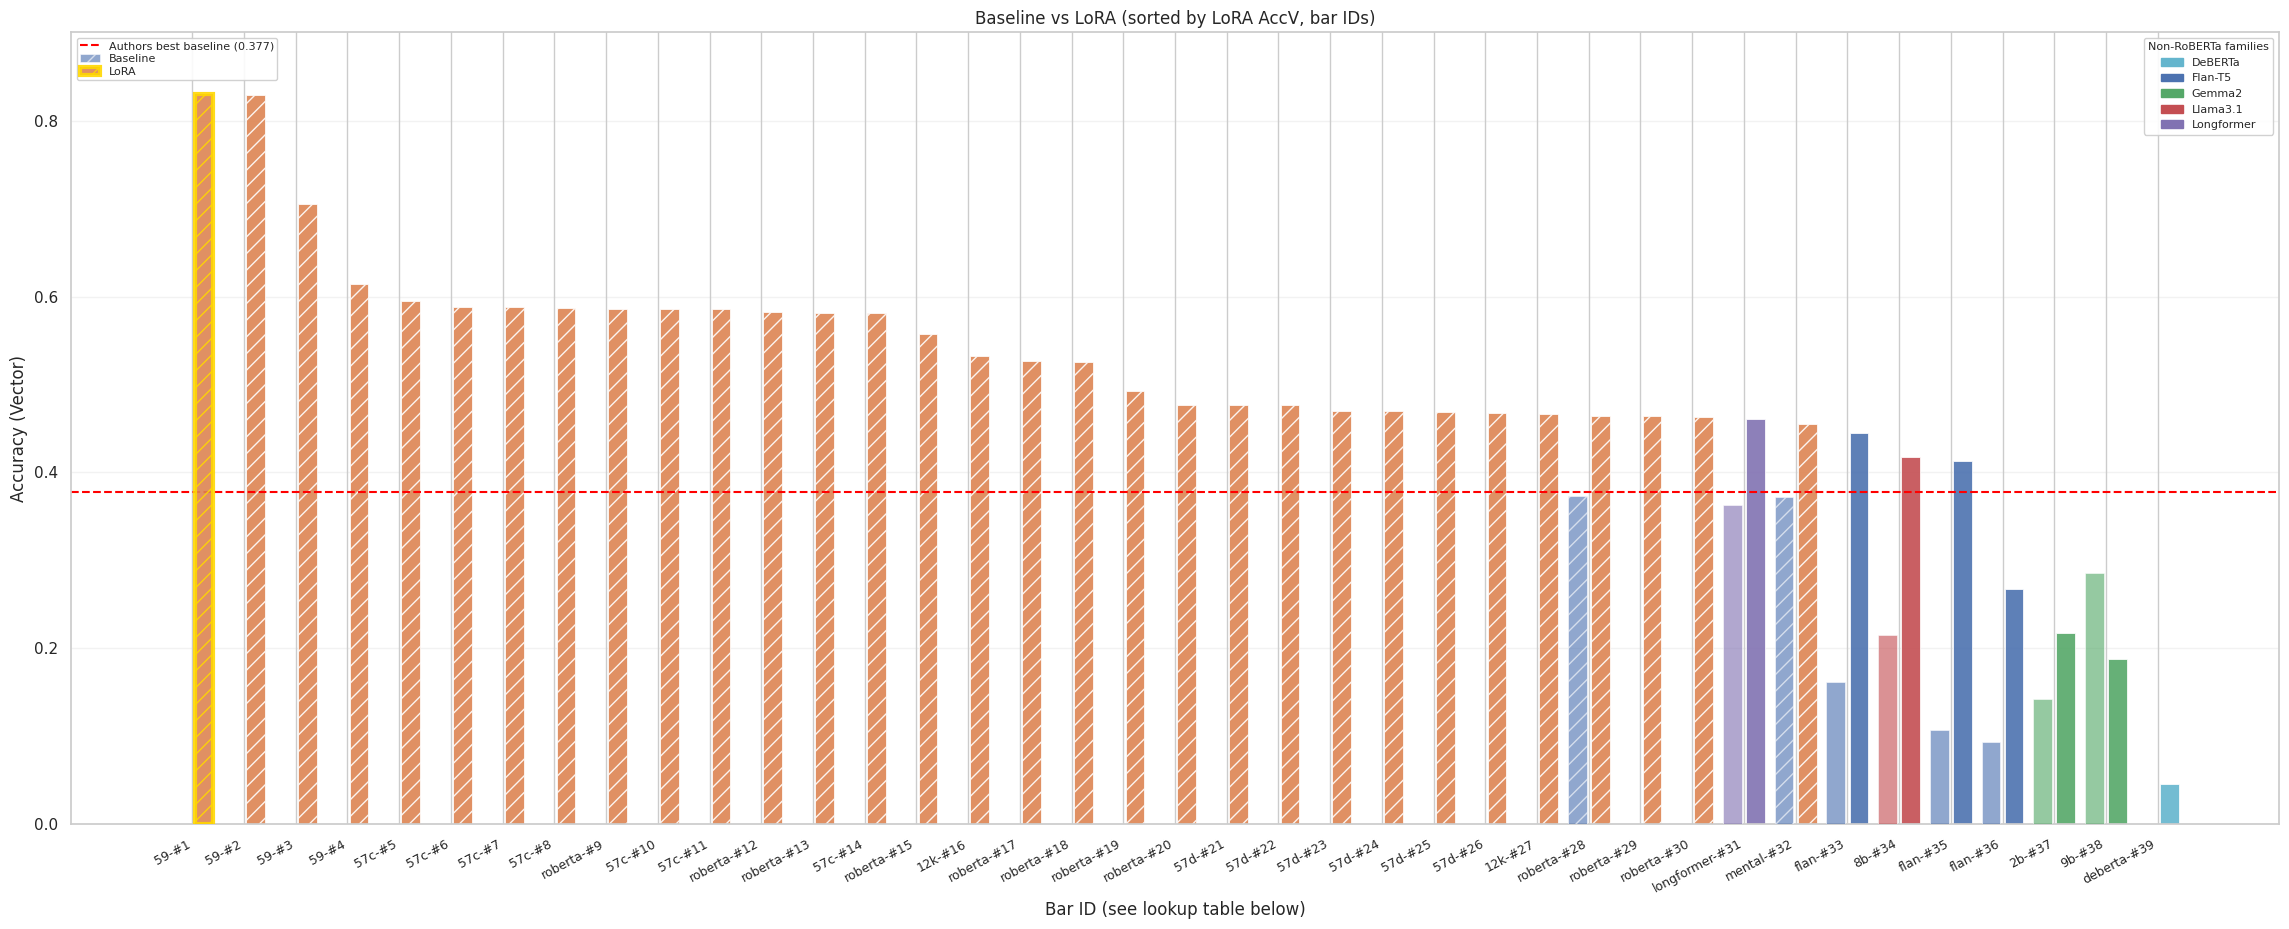

,bar_id,display_label,family,baseline_accv,lora_accv,delta_accv,base_model_id
0,59-#1,59-continue-from-57c-final-e4-lr4e6-plus20e-pl...,Roberta,NaN,0.830411,NaN,roberta_large_59_continue_from_57c_final_e4_lr...
1,59-#2,59-continue-from-57c-final-e4-lr4e6-plus20e-pl...,Roberta,NaN,0.829473,NaN,roberta_large_59_continue_from_57c_final_e4_lr...
2,59-#3,59-continue-from-57c-final-e4-lr4e6-plus20e,Roberta,NaN,0.705303,NaN,roberta_large_59_continue_from_57c_final_e4_lr...
3,59-#4,59-continue-from-57c-final-e4-lr4e6,Roberta,NaN,0.614556,NaN,roberta_large_59_continue_from_57c_final_e4_lr4e6
4,57c-#5,57c-final-full-rank64-noval-canonical,Roberta,NaN,0.594715,NaN,roberta_large_57c_final_full_rank64_noval_cano...
5,57c-#6,57c-ensemble-top2,Roberta,NaN,0.588113,NaN,roberta_large_57c_ensemble_top2
6,57c-#7,57c-full-qkv-dense-rank64-lowdrop,Roberta,NaN,0.587843,NaN,roberta_large_57c_full_qkv_dense_rank64_lowdrop
7,57c-#8,57c-full-qkv-dense-rank64-seed1337,Roberta,NaN,0.587392,NaN,roberta_large_57c_full_qkv_dense_rank64_seed1337
8,roberta-#9,roberta-large-large-full-qkv-dense-rank48-lr1e5,Roberta,NaN,0.586255,NaN,roberta_large_large_full_qkv_dense_rank48_lr1e5
9,57c-#10,57c-full-qkv-dense-rank48,Roberta,NaN,0.585804,NaN,roberta_large_57c_full_qkv_dense_rank48


In [3]:
# Cell 2: Basic grouped bar chart (baseline vs LoRA where available) with bar IDs.
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if 'base_df' not in globals() or 'lora_plot' not in globals():
    raise RuntimeError('Run Cell 1 first to build base_df and lora_plot.')

bar_df = lora_plot[['base_model_id', 'base_label', 'base_accv', 'accv']].copy()
bar_df = bar_df.dropna(subset=['accv'])
bar_df['baseline_accv'] = pd.to_numeric(bar_df['base_accv'], errors='coerce')
bar_df['lora_accv'] = pd.to_numeric(bar_df['accv'], errors='coerce')


def shorten_display_label(model_id, base_label):
    model_id_clean = str(model_id).replace('_', '-').strip('-')
    tokens = [t for t in model_id_clean.split('-') if t]

    # Prefer notebook-like run prefix (e.g., 59, 57c) onward.
    run_idx = None
    for i, tok in enumerate(tokens):
        if re.match(r'^\d+[a-zA-Z]*$', tok):
            run_idx = i
            break

    if run_idx is not None:
        return '-'.join(tokens[run_idx:])

    if isinstance(base_label, str) and base_label.strip():
        return base_label.strip()

    return model_id_clean


def make_bar_id(display_label, rank_idx):
    label = str(display_label).strip()
    if not label:
        prefix = 'id'
    else:
        # Prefer leading run token (e.g., 59, 57c). Fallback to first label token.
        m = re.match(r'^([0-9]+[a-zA-Z]*)', label)
        if m:
            prefix = m.group(1).lower()
        else:
            prefix = re.split(r'[-_\s]+', label)[0].lower()
            prefix = re.sub(r'[^a-z0-9]+', '', prefix) or 'id'
    return f"{prefix}-#{int(rank_idx)}"


def infer_family(model_id: str) -> str:
    mid = str(model_id).lower()
    if 'roberta' in mid:
        return 'Roberta'
    if 'longformer' in mid:
        return 'Longformer'
    if 'flan' in mid or 't5' in mid:
        return 'Flan-T5'
    if 'gemma' in mid:
        return 'Gemma2'
    if 'llama' in mid:
        return 'Llama3.1'
    if 'gpt' in mid:
        return 'GPT'
    if 'deberta' in mid:
        return 'DeBERTa'
    return 'Other'


bar_df['display_label'] = bar_df.apply(
    lambda r: shorten_display_label(r['base_model_id'], r.get('base_label')),
    axis=1,
)
bar_df['family'] = bar_df['base_model_id'].astype(str).apply(infer_family)
bar_df = bar_df[['base_model_id', 'display_label', 'family', 'baseline_accv', 'lora_accv']]
bar_df = bar_df.sort_values('lora_accv', ascending=False).reset_index(drop=True)
bar_df['bar_id'] = [make_bar_id(lbl, i + 1) for i, lbl in enumerate(bar_df['display_label'].tolist())]

if bar_df.empty:
    print('No completed LoRA rows yet in all_models_metrics.csv')
else:
    # Keep groups tight without overlap between baseline and LoRA bars.
    group_spacing = 0.58 if len(bar_df) > 20 else 0.76
    x = np.arange(len(bar_df)) * group_spacing
    width = 0.21
    offset = 0.13

    fig_width = min(24, max(11, len(bar_df) * 0.9))
    fig_height = 11.0
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Family-aware color coding: keep RoBERTa as default pair, color non-RoBERTa by family.
    family_colors = {
        'Flan-T5': '#4C72B0',
        'GPT': '#DD8452',
        'Gemma2': '#55A868',
        'Llama3.1': '#C44E52',
        'Longformer': '#8172B2',
        'DeBERTa': '#64B5CD',
        'Other': '#999999',
    }
    roberta_baseline_color = '#4C72B0'
    roberta_lora_color = '#DD8452'

    baseline_vals = bar_df['baseline_accv'].fillna(0.0)
    baseline_colors = []
    lora_colors = []
    for fam in bar_df['family'].tolist():
        if fam == 'Roberta':
            baseline_colors.append(roberta_baseline_color)
            lora_colors.append(roberta_lora_color)
        else:
            fam_color = family_colors.get(fam, family_colors['Other'])
            baseline_colors.append(fam_color)
            lora_colors.append(fam_color)

    baseline_bars = ax.bar(
        x - offset,
        baseline_vals,
        width=width,
        label='Baseline',
        color=baseline_colors,
        alpha=0.62,
        edgecolor='white',
        linewidth=0.6,
        zorder=3,
    )
    lora_bars = ax.bar(
        x + offset,
        bar_df['lora_accv'],
        width=width,
        label='LoRA',
        color=lora_colors,
        alpha=0.9,
        edgecolor='white',
        linewidth=0.6,
        zorder=2,
    )

    # Keep RoBERTa visually distinct with hatching.
    roberta_mask = bar_df['family'].astype(str).eq('Roberta')
    for idx, is_rob in enumerate(roberta_mask.tolist()):
        if is_rob:
            baseline_bars[idx].set_hatch('//')
            lora_bars[idx].set_hatch('//')

    # Highlight the highest bar across baseline+LoRA.
    all_bars = list(baseline_bars) + list(lora_bars)
    if all_bars:
        best_bar = max(all_bars, key=lambda b: b.get_height())
        best_bar.set_edgecolor('gold')
        best_bar.set_linewidth(3.0)
        best_bar.set_zorder(5)

    authors_best_accv = float(base_df['accv'].max())
    ax.axhline(
        y=authors_best_accv,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f"Authors best baseline ({authors_best_accv:.3f})",
    )

    # Use bar IDs on x-axis; rotate slightly for readability.
    ax.set_xticks(x)
    ax.set_xticklabels(bar_df['bar_id'].astype(str).tolist(), rotation=28, ha='right', fontsize=9)
    ax.set_xlabel('Bar ID (see lookup table below)')
    ax.set_ylabel('Accuracy (Vector)')
    ax.set_title('Baseline vs LoRA (sorted by LoRA AccV, bar IDs)')

    # Tight y-scale around actual values.
    all_vals = np.concatenate([
        baseline_vals.to_numpy(dtype=float),
        bar_df['lora_accv'].to_numpy(dtype=float),
        np.array([authors_best_accv], dtype=float),
    ])
    y_min = max(0.0, float(np.nanmin(all_vals)) - 0.04)
    y_max = float(np.nanmax(all_vals)) + 0.07
    ax.set_ylim(y_min, y_max)

    # Legends: metric legend + family legend for non-RoBERTa runs.
    main_legend = ax.legend(
        loc='upper left',
        fontsize=8,
        framealpha=0.9,
        borderpad=0.3,
        labelspacing=0.25,
        handlelength=1.8,
    )
    ax.add_artist(main_legend)

    present_non_roberta_families = [
        f for f in bar_df['family'].dropna().astype(str).unique().tolist()
        if f != 'Roberta'
    ]
    if present_non_roberta_families:
        family_handles = [
            mpatches.Patch(color=family_colors.get(f, family_colors['Other']), label=f)
            for f in sorted(present_non_roberta_families)
        ]
        ax.legend(handles=family_handles, title='Non-RoBERTa families', loc='upper right', fontsize=8, title_fontsize=8, framealpha=0.9)

    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.2, left=0.07, right=0.99, top=0.92)
    plt.show()

    bar_df['delta_accv'] = bar_df['lora_accv'] - bar_df['baseline_accv']
    lookup_df = bar_df[['bar_id', 'display_label', 'family', 'baseline_accv', 'lora_accv', 'delta_accv', 'base_model_id']].copy()
    lookup_df = lookup_df.sort_values('lora_accv', ascending=False).reset_index(drop=True)
    display(lookup_df)


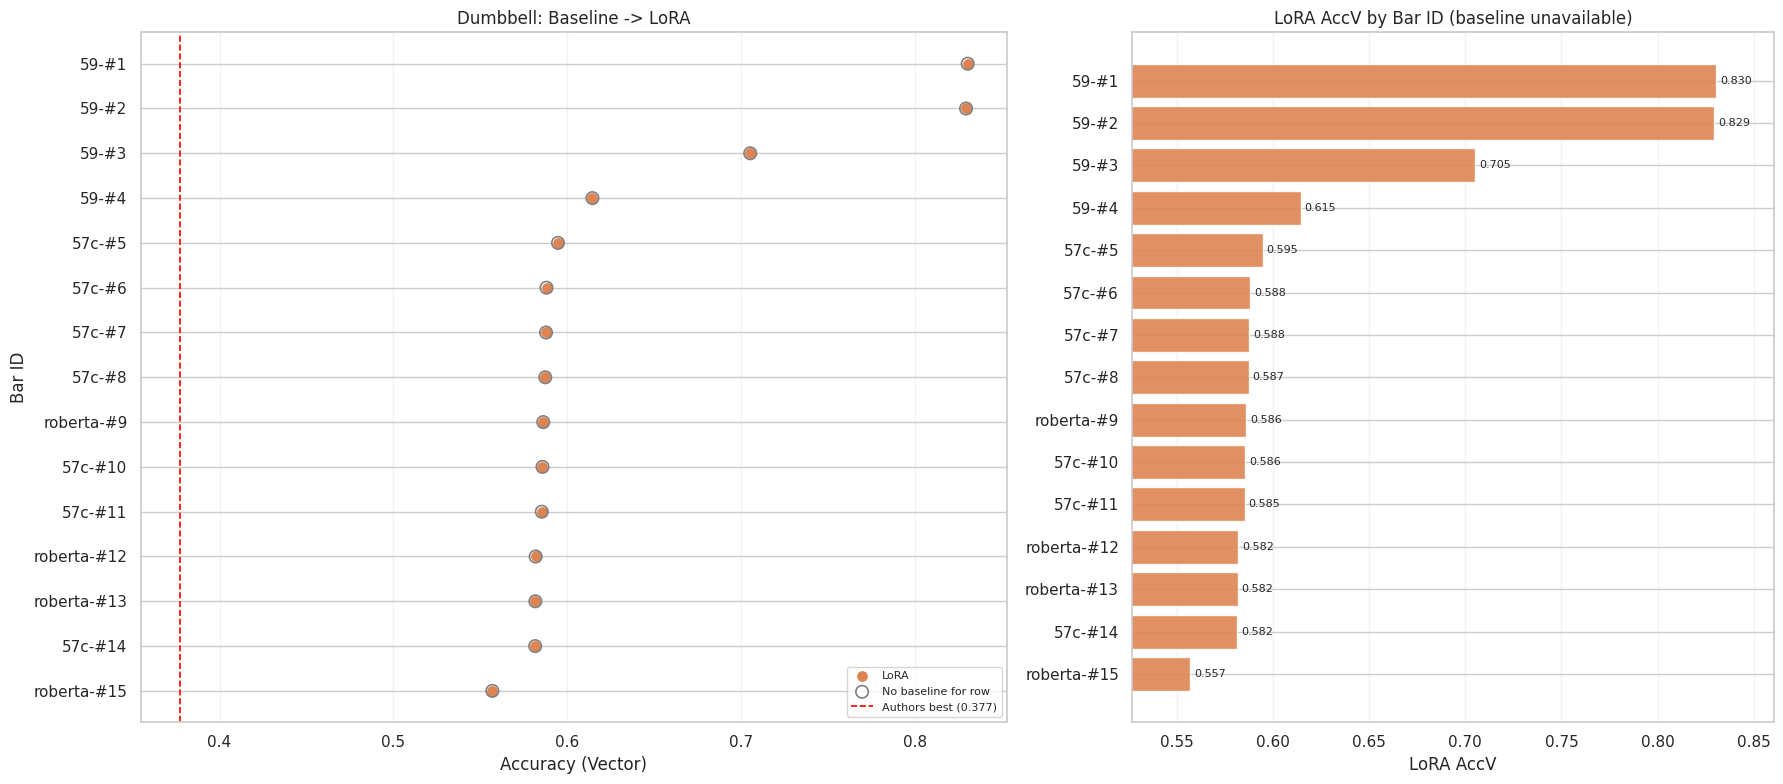

,bar_id,display_label,family,baseline_accv,lora_accv,delta_accv,has_baseline,base_model_id
0,59-#1,59-continue-from-57c-final-e4-lr4e6-plus20e-pl...,Roberta,NaN,0.830411,NaN,False,roberta_large_59_continue_from_57c_final_e4_lr...
1,59-#2,59-continue-from-57c-final-e4-lr4e6-plus20e-pl...,Roberta,NaN,0.829473,NaN,False,roberta_large_59_continue_from_57c_final_e4_lr...
2,59-#3,59-continue-from-57c-final-e4-lr4e6-plus20e,Roberta,NaN,0.705303,NaN,False,roberta_large_59_continue_from_57c_final_e4_lr...
3,59-#4,59-continue-from-57c-final-e4-lr4e6,Roberta,NaN,0.614556,NaN,False,roberta_large_59_continue_from_57c_final_e4_lr4e6
4,57c-#5,57c-final-full-rank64-noval-canonical,Roberta,NaN,0.594715,NaN,False,roberta_large_57c_final_full_rank64_noval_cano...
5,57c-#6,57c-ensemble-top2,Roberta,NaN,0.588113,NaN,False,roberta_large_57c_ensemble_top2
6,57c-#7,57c-full-qkv-dense-rank64-lowdrop,Roberta,NaN,0.587843,NaN,False,roberta_large_57c_full_qkv_dense_rank64_lowdrop
7,57c-#8,57c-full-qkv-dense-rank64-seed1337,Roberta,NaN,0.587392,NaN,False,roberta_large_57c_full_qkv_dense_rank64_seed1337
8,roberta-#9,roberta-large-large-full-qkv-dense-rank48-lr1e5,Roberta,NaN,0.586255,NaN,False,roberta_large_large_full_qkv_dense_rank48_lr1e5
9,57c-#10,57c-full-qkv-dense-rank48,Roberta,NaN,0.585804,NaN,False,roberta_large_57c_full_qkv_dense_rank48


In [4]:
# Cell 3: Alternative readable view (dumbbell + gain/loss) using the same bar IDs.
import numpy as np
import matplotlib.pyplot as plt

if 'bar_df' not in globals() or bar_df.empty:
    raise RuntimeError('Run Cell 2 first to build bar_df and bar IDs.')

plot_n = min(15, len(bar_df))
alt_df = bar_df.sort_values('lora_accv', ascending=False).head(plot_n).copy()
alt_df = alt_df.sort_values('lora_accv', ascending=True).reset_index(drop=True)
alt_df['has_baseline'] = alt_df['baseline_accv'].notna()
alt_df['delta_accv'] = alt_df['lora_accv'] - alt_df['baseline_accv']

y = np.arange(len(alt_df))
authors_best_accv = float(base_df['accv'].max())

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, max(8, plot_n * 0.5)),
    gridspec_kw={'width_ratios': [1.35, 1.0]},
)

# Left: dumbbell baseline->LoRA
ax = axes[0]
for i, row in alt_df.iterrows():
    if bool(row['has_baseline']):
        ax.plot([row['baseline_accv'], row['lora_accv']], [i, i], color='0.65', linewidth=1.5, zorder=1)

if alt_df['has_baseline'].any():
    ax.scatter(
        alt_df.loc[alt_df['has_baseline'], 'baseline_accv'],
        y[alt_df['has_baseline'].to_numpy()],
        s=45,
        color='#4C72B0',
        label='Baseline',
        zorder=3,
    )

ax.scatter(alt_df['lora_accv'], y, s=45, color='#DD8452', label='LoRA', zorder=4)

# Mark rows where baseline is unavailable.
missing_mask = ~alt_df['has_baseline']
if missing_mask.any():
    ax.scatter(
        alt_df.loc[missing_mask, 'lora_accv'],
        y[missing_mask.to_numpy()],
        s=80,
        facecolors='none',
        edgecolors='gray',
        linewidths=1.2,
        label='No baseline for row',
        zorder=5,
    )

ax.axvline(authors_best_accv, color='red', linestyle='--', linewidth=1.2, label=f'Authors best ({authors_best_accv:.3f})')
ax.set_yticks(y)
ax.set_yticklabels(alt_df['bar_id'].astype(str).tolist())
ax.set_xlabel('Accuracy (Vector)')
ax.set_ylabel('Bar ID')
ax.set_title('Dumbbell: Baseline -> LoRA')
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='lower right', fontsize=8)

# Right: gain/loss bars when available; otherwise show LoRA AccV.
ax2 = axes[1]
valid_delta = alt_df['delta_accv'].notna()
if valid_delta.any():
    delta_vals = alt_df['delta_accv'].to_numpy(dtype=float)
    colors = np.where(delta_vals >= 0.0, '#55A868', '#C44E52')

    # Plot deltas only where valid baseline exists.
    y_valid = y[valid_delta.to_numpy()]
    vals_valid = delta_vals[valid_delta.to_numpy()]
    cols_valid = colors[valid_delta.to_numpy()]

    bars = ax2.barh(y_valid, vals_valid, color=cols_valid, alpha=0.9)
    ax2.axvline(0.0, color='black', linewidth=1.0)

    # Annotate delta values.
    for yi, v in zip(y_valid, vals_valid):
        dx = 0.0015 if v >= 0 else -0.0015
        ha = 'left' if v >= 0 else 'right'
        ax2.text(v + dx, yi, f'{v:+.3f}', va='center', ha=ha, fontsize=8)

    # Mark missing-baseline rows as N/A at x=0.
    if (~valid_delta).any():
        y_na = y[(~valid_delta).to_numpy()]
        ax2.scatter(np.zeros(len(y_na)), y_na, marker='x', color='gray', s=35, label='N/A baseline', zorder=4)
        for yi in y_na:
            ax2.text(0.001, yi, 'n/a', va='center', ha='left', fontsize=8, color='gray')

    # Auto-scale around observed deltas.
    max_abs = float(np.nanmax(np.abs(vals_valid))) if len(vals_valid) else 0.0
    span = max(0.01, max_abs * 1.25)
    ax2.set_xlim(-span, span)
    ax2.set_xlabel('LoRA - Baseline (AccV)')
    ax2.set_title('Gain/Loss by Bar ID')
else:
    # Fallback when baseline is unavailable in selected rows.
    vals = alt_df['lora_accv'].to_numpy(dtype=float)
    bars = ax2.barh(y, vals, color='#DD8452', alpha=0.9)
    ax2.axvline(authors_best_accv, color='red', linestyle='--', linewidth=1.2)
    for yi, v in zip(y, vals):
        ax2.text(v + 0.002, yi, f'{v:.3f}', va='center', ha='left', fontsize=8)
    ax2.set_xlim(max(0.0, float(np.nanmin(vals)) - 0.03), float(np.nanmax(vals)) + 0.03)
    ax2.set_xlabel('LoRA AccV')
    ax2.set_title('LoRA AccV by Bar ID (baseline unavailable)')

ax2.set_yticks(y)
ax2.set_yticklabels(alt_df['bar_id'].astype(str).tolist())
ax2.grid(axis='x', alpha=0.25)

fig.tight_layout()
plt.show()

alt_lookup = alt_df[['bar_id', 'display_label', 'family', 'baseline_accv', 'lora_accv', 'delta_accv', 'has_baseline', 'base_model_id']].copy()
alt_lookup = alt_lookup.sort_values('lora_accv', ascending=False).reset_index(drop=True)
display(alt_lookup)


/localscratch-nvme/5029555/ipykernel_3457064/1846992791.py:296: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', max(3, len(seg_names)))


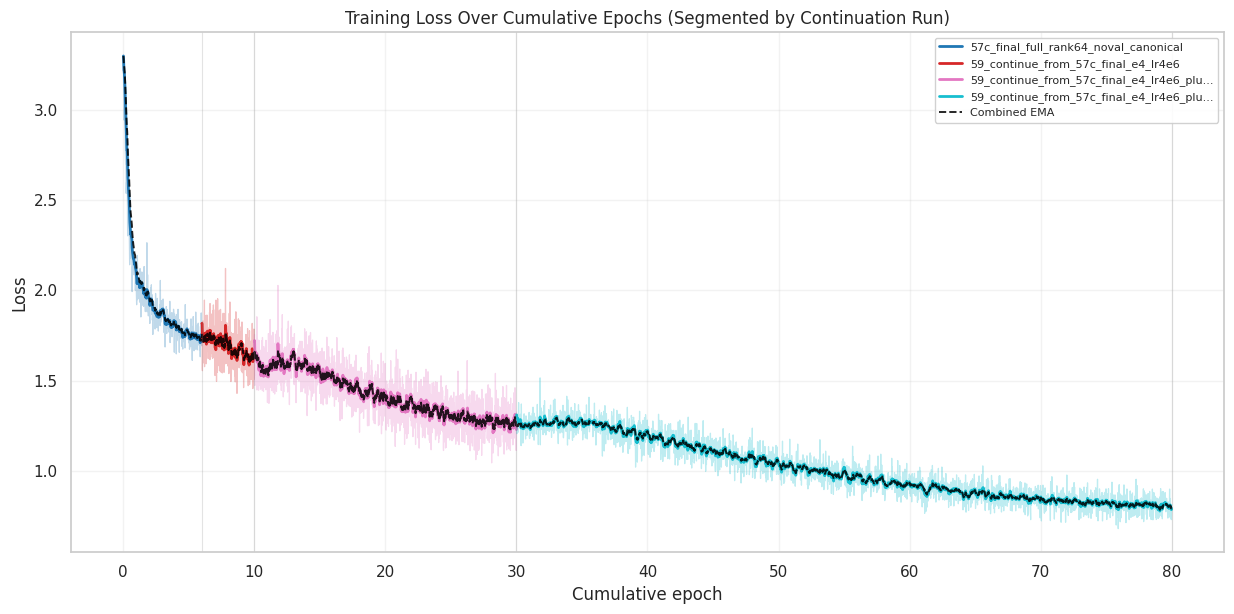

,experiment_name,epoch_start,epoch_end,epochs,epochs_effective,accv,continued_from,run_dir
0,57c_final_full_rank64_noval_canonical,0.0,6.0,6.0,6.0,0.594715,NaN,/home/rameyjm7/workspace/masked-emotion-lora-b...
1,59_continue_from_57c_final_e4_lr4e6,6.0,10.0,4.0,4.0,0.614556,57c_final_full_rank64_noval_canonical,/home/rameyjm7/workspace/masked-emotion-lora-b...
2,59_continue_from_57c_final_e4_lr4e6_plus20e,10.0,30.0,20.0,20.0,0.705303,59_continue_from_57c_final_e4_lr4e6,/home/rameyjm7/workspace/masked-emotion-lora-b...
3,59_continue_from_57c_final_e4_lr4e6_plus20e_pl...,30.0,80.0,50.0,50.0,0.830411,59_continue_from_57c_final_e4_lr4e6_plus20e,/home/rameyjm7/workspace/masked-emotion-lora-b...


In [5]:
# Cell 4: Plot cumulative training loss over epochs for RoBERTa continuation runs.
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROBERTA_SUMMARY_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'roberta_large_experiments' / 'experiment_summary.csv'


def _as_float(x, default=np.nan):
    try:
        if pd.isna(x):
            return float(default)
        return float(x)
    except Exception:
        return float(default)


def _resolve_run_dir(raw_run_dir) -> Path:
    raw = str(raw_run_dir or '').strip()
    if not raw:
        return Path('.')
    # Some rows (ensembles) may contain comma-separated paths; use first real run path.
    run_path = raw.split(',')[0].strip()
    return Path(run_path)


def _extract_experiment_name_from_adapter_path(adapter_path: Path) -> str | None:
    if not adapter_path or str(adapter_path) == '.':
        return None
    p = Path(adapter_path)

    # Common pattern: .../<exp_name>/trainer_state/checkpoint-xxxx
    if p.name.startswith('checkpoint-') and p.parent.name == 'trainer_state':
        return p.parent.parent.name

    # Direct run dir pattern: .../<exp_name>
    if (p / 'training_summary.json').exists() or (p / 'trainer_state').exists():
        return p.name

    return p.name if p.name else None


def resolve_best_adapter_path(run_dir: Path) -> Path:
    summary_path = run_dir / 'training_summary.json'
    if summary_path.exists():
        try:
            obj = json.loads(summary_path.read_text(encoding='utf-8'))
            ckpt = obj.get('best_model_checkpoint')
            if ckpt:
                ckpt_path = Path(str(ckpt))
                if ckpt_path.exists():
                    return ckpt_path
        except Exception:
            pass

    ckpt_root = run_dir / 'trainer_state'
    if ckpt_root.exists():
        checkpoints = sorted(
            [d for d in ckpt_root.glob('checkpoint-*') if d.is_dir()],
            key=lambda d: int(d.name.split('-')[-1]) if d.name.split('-')[-1].isdigit() else -1,
        )
        if checkpoints:
            return checkpoints[-1]

    return run_dir


def _load_trainer_state(run_dir: Path):
    best = resolve_best_adapter_path(run_dir)
    best_state = best / 'trainer_state.json'
    if best_state.exists():
        return best_state

    ckpt_root = run_dir / 'trainer_state'
    if ckpt_root.exists():
        states = sorted(
            [d / 'trainer_state.json' for d in ckpt_root.glob('checkpoint-*') if (d / 'trainer_state.json').exists()],
            key=lambda f: int(f.parent.name.split('-')[-1]) if f.parent.name.split('-')[-1].isdigit() else -1,
        )
        if states:
            return states[-1]

    direct = run_dir / 'trainer_state' / 'trainer_state.json'
    if direct.exists():
        return direct

    return None


def _infer_parent_from_run(run_dir: Path, known_names: set[str]) -> str | None:
    tpath = run_dir / 'training_summary.json'
    if not tpath.exists():
        return None
    try:
        obj = json.loads(tpath.read_text(encoding='utf-8'))
    except Exception:
        return None

    adapter = obj.get('init_adapter_dir')
    if not adapter:
        return None

    inferred_name = _extract_experiment_name_from_adapter_path(Path(str(adapter)))
    if inferred_name in known_names:
        return inferred_name

    # Fuzzy fallback by prefix token (e.g., 57c...)
    if inferred_name:
        tok_match = re.match(r'^([0-9]+[a-zA-Z]*)', inferred_name)
        if tok_match:
            tok = tok_match.group(1).lower()
            candidates = [n for n in known_names if str(n).lower().startswith(tok)]
            if candidates:
                return sorted(candidates)[-1]
    return None


def _infer_epochs_from_run(run_dir: Path) -> float:
    # 1) trainer state root epoch
    state_path = _load_trainer_state(run_dir)
    if state_path is not None and state_path.exists():
        try:
            st = json.loads(state_path.read_text(encoding='utf-8'))
            ep = _as_float(st.get('epoch'), np.nan)
            if not np.isnan(ep) and ep > 0:
                return float(ep)

            logs = st.get('log_history', []) or []
            if logs:
                ldf = pd.DataFrame(logs)
                if 'epoch' in ldf.columns:
                    em = pd.to_numeric(ldf['epoch'], errors='coerce').dropna()
                    if not em.empty:
                        mx = float(em.max())
                        if mx > 0:
                            return mx
        except Exception:
            pass

    # 2) training_summary train_runtime exists but no epoch info; cannot convert safely.
    return float('nan')


def _build_roberta_chain(summary_df: pd.DataFrame, leaf_experiment: str | None = None) -> pd.DataFrame:
    if summary_df.empty:
        return pd.DataFrame()

    sdf = summary_df.copy()
    if 'timestamp_utc' in sdf.columns:
        sdf['timestamp_utc'] = pd.to_datetime(sdf['timestamp_utc'], errors='coerce')
        sdf = sdf.sort_values('timestamp_utc')

    # Keep latest row per experiment name.
    sdf = sdf.groupby('experiment_name', as_index=False).tail(1).copy()

    if leaf_experiment is None:
        def _continuation_rank(name: str):
            s = str(name)
            plus_tokens = re.findall(r'_plus(\d+)e', s)
            # Primary: sum of explicit +epochs in name (e.g., +20e+50e => 70)
            epoch_sum = sum(int(x) for x in plus_tokens) if plus_tokens else 0
            # Secondary: depth by number of continuation hops in name.
            depth = s.count('_plus')
            return (epoch_sum, depth)

        cand59 = sdf[sdf['experiment_name'].astype(str).str.startswith('59_continue_from_57c_final_e4_lr4e6')]
        if not cand59.empty:
            c59 = cand59.copy()
            c59['rank_tuple'] = c59['experiment_name'].map(_continuation_rank)
            c59 = c59.sort_values(['rank_tuple', 'timestamp_utc'])
            leaf_experiment = c59.iloc[-1]['experiment_name']
        else:
            cand = sdf[sdf['experiment_name'].astype(str).str.startswith('59_')]
            if not cand.empty:
                leaf_experiment = cand.sort_values('timestamp_utc').iloc[-1]['experiment_name']
            else:
                leaf_experiment = sdf.sort_values('timestamp_utc').iloc[-1]['experiment_name']

    by_name = {str(r['experiment_name']): r for _, r in sdf.iterrows()}
    known = set(by_name.keys())

    chain = []
    cur = str(leaf_experiment)
    seen = set()

    while cur in by_name and cur not in seen:
        seen.add(cur)
        row = by_name[cur]
        chain.append(row)

        prev = row.get('continued_from') if isinstance(row, pd.Series) else None
        if isinstance(prev, str) and prev.strip():
            cur = prev.strip()
            continue

        # Backfill missing parent link from run metadata.
        run_dir = _resolve_run_dir(row.get('run_dir', ''))
        inferred_prev = _infer_parent_from_run(run_dir, known)
        if inferred_prev and inferred_prev not in seen:
            cur = inferred_prev
            continue

        break

    if not chain:
        return pd.DataFrame()

    cdf = pd.DataFrame(list(reversed(chain))).reset_index(drop=True)

    # Build cumulative epoch spans, backfilling missing epochs from trainer state.
    starts, ends, eps_eff = [], [], []
    cursor = 0.0
    for _, r in cdf.iterrows():
        run_dir = _resolve_run_dir(r.get('run_dir', ''))

        ep = _as_float(r.get('epochs'), np.nan)
        if np.isnan(ep) or ep <= 0:
            ep = _infer_epochs_from_run(run_dir)
        if np.isnan(ep) or ep <= 0:
            ep = 0.0

        starts.append(cursor)
        cursor += float(ep)
        ends.append(cursor)
        eps_eff.append(float(ep))

    cdf['epoch_start'] = starts
    cdf['epoch_end'] = ends
    cdf['epochs_effective'] = eps_eff
    return cdf


def plot_roberta_epoch_history(leaf_experiment: str | None = None):
    if not ROBERTA_SUMMARY_PATH.exists():
        raise FileNotFoundError(f'Missing summary file: {ROBERTA_SUMMARY_PATH}')

    summary_df = pd.read_csv(ROBERTA_SUMMARY_PATH)
    chain_df = _build_roberta_chain(summary_df, leaf_experiment=leaf_experiment)
    if chain_df.empty:
        raise RuntimeError('Could not build continuation chain from experiment_summary.csv')

    train_rows = []
    accv_rows = []

    for _, r in chain_df.iterrows():
        run_dir = _resolve_run_dir(r.get('run_dir', ''))
        if not run_dir.exists():
            continue

        epoch_offset = float(r.get('epoch_start', 0.0))
        exp_name = str(r.get('experiment_name'))
        exp_accv = _as_float(r.get('accv'))
        if not np.isnan(exp_accv):
            accv_rows.append({
                'experiment_name': exp_name,
                'epoch_end': float(r.get('epoch_end', np.nan)),
                'accv': exp_accv,
            })

        state_path = _load_trainer_state(run_dir)
        if state_path is None:
            continue
        try:
            state_obj = json.loads(state_path.read_text(encoding='utf-8'))
        except Exception:
            continue

        logs = state_obj.get('log_history', []) or []
        if not logs:
            continue

        ldf = pd.DataFrame(logs)
        if 'loss' in ldf.columns:
            tdf = ldf[ldf['loss'].notna()].copy()
            if not tdf.empty:
                tdf['epoch'] = pd.to_numeric(tdf.get('epoch'), errors='coerce')
                tdf['loss'] = pd.to_numeric(tdf.get('loss'), errors='coerce')
                tdf = tdf.dropna(subset=['epoch', 'loss'])
                if not tdf.empty:
                    tdf['epoch_global'] = tdf['epoch'] + epoch_offset
                    tdf['experiment_name'] = exp_name
                    train_rows.append(tdf[['epoch_global', 'loss', 'experiment_name']])

    train_df = pd.concat(train_rows, ignore_index=True) if train_rows else pd.DataFrame(columns=['epoch_global', 'loss', 'experiment_name'])
    accv_df = pd.DataFrame(accv_rows)

    fig, ax = plt.subplots(figsize=(12.5, 6.3))
    if not train_df.empty:
        train_df = train_df.sort_values('epoch_global')

        # Plot each continuation segment as its own color trace.
        seg_names = train_df['experiment_name'].astype(str).dropna().unique().tolist()
        cmap = plt.cm.get_cmap('tab10', max(3, len(seg_names)))

        for i, name in enumerate(seg_names):
            seg = train_df[train_df['experiment_name'].astype(str) == str(name)].copy()
            if seg.empty:
                continue
            seg = seg.sort_values('epoch_global')
            color = cmap(i)
            short_name = str(name)
            if len(short_name) > 42:
                short_name = short_name[:39] + '...'

            ax.plot(seg['epoch_global'], seg['loss'], color=color, alpha=0.28, linewidth=0.9)
            ax.plot(
                seg['epoch_global'],
                seg['loss'].ewm(span=12, adjust=False).mean(),
                color=color,
                linewidth=2.0,
                label=short_name,
            )

        # Combined trend across full concatenated timeline.
        ax.plot(
            train_df['epoch_global'],
            train_df['loss'].ewm(span=20, adjust=False).mean(),
            color='black',
            linestyle='--',
            linewidth=1.4,
            alpha=0.85,
            label='Combined EMA',
        )

        for rr in chain_df.itertuples(index=False):
            ax.axvline(float(rr.epoch_end), color='gray', linewidth=0.8, alpha=0.22)

        ax.set_title('Training Loss Over Cumulative Epochs (Segmented by Continuation Run)')
        ax.set_xlabel('Cumulative epoch')
        ax.set_ylabel('Loss')
        ax.grid(alpha=0.25)
        ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    else:
        ax.text(0.5, 0.5, 'No training-loss logs found in chain.', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()

    fig.tight_layout()
    plt.show()

    chain_view = chain_df[['experiment_name', 'epoch_start', 'epoch_end', 'epochs', 'epochs_effective', 'accv', 'continued_from', 'run_dir']].copy()
    # Clean display: fill missing declared epochs with inferred effective epochs.
    chain_view['epochs'] = pd.to_numeric(chain_view['epochs'], errors='coerce')
    chain_view['epochs_effective'] = pd.to_numeric(chain_view['epochs_effective'], errors='coerce')
    chain_view['epochs'] = chain_view['epochs'].fillna(chain_view['epochs_effective'])
    display(chain_view)

    return chain_df, train_df, pd.DataFrame(), accv_df


CHAIN_DF, TRAIN_EPOCH_DF, EVAL_EPOCH_DF, ACCV_EPOCH_DF = plot_roberta_epoch_history()


Using best run: roberta_large_59_continue_from_57c_final_e4_lr4e6_plus20e_plus50e_r2
AccV: 0.8304112554112554
Clean output: /home/rameyjm7/workspace/masked-emotion-lora-benchmark/outputs/metrics/roberta_large_experiments/59_continue_from_57c_final_e4_lr4e6_plus20e_plus50e_r2/roberta_large_59_continue_from_57c_final_e4_lr4e6_plus20e_plus50e_r2_lora_clean.csv


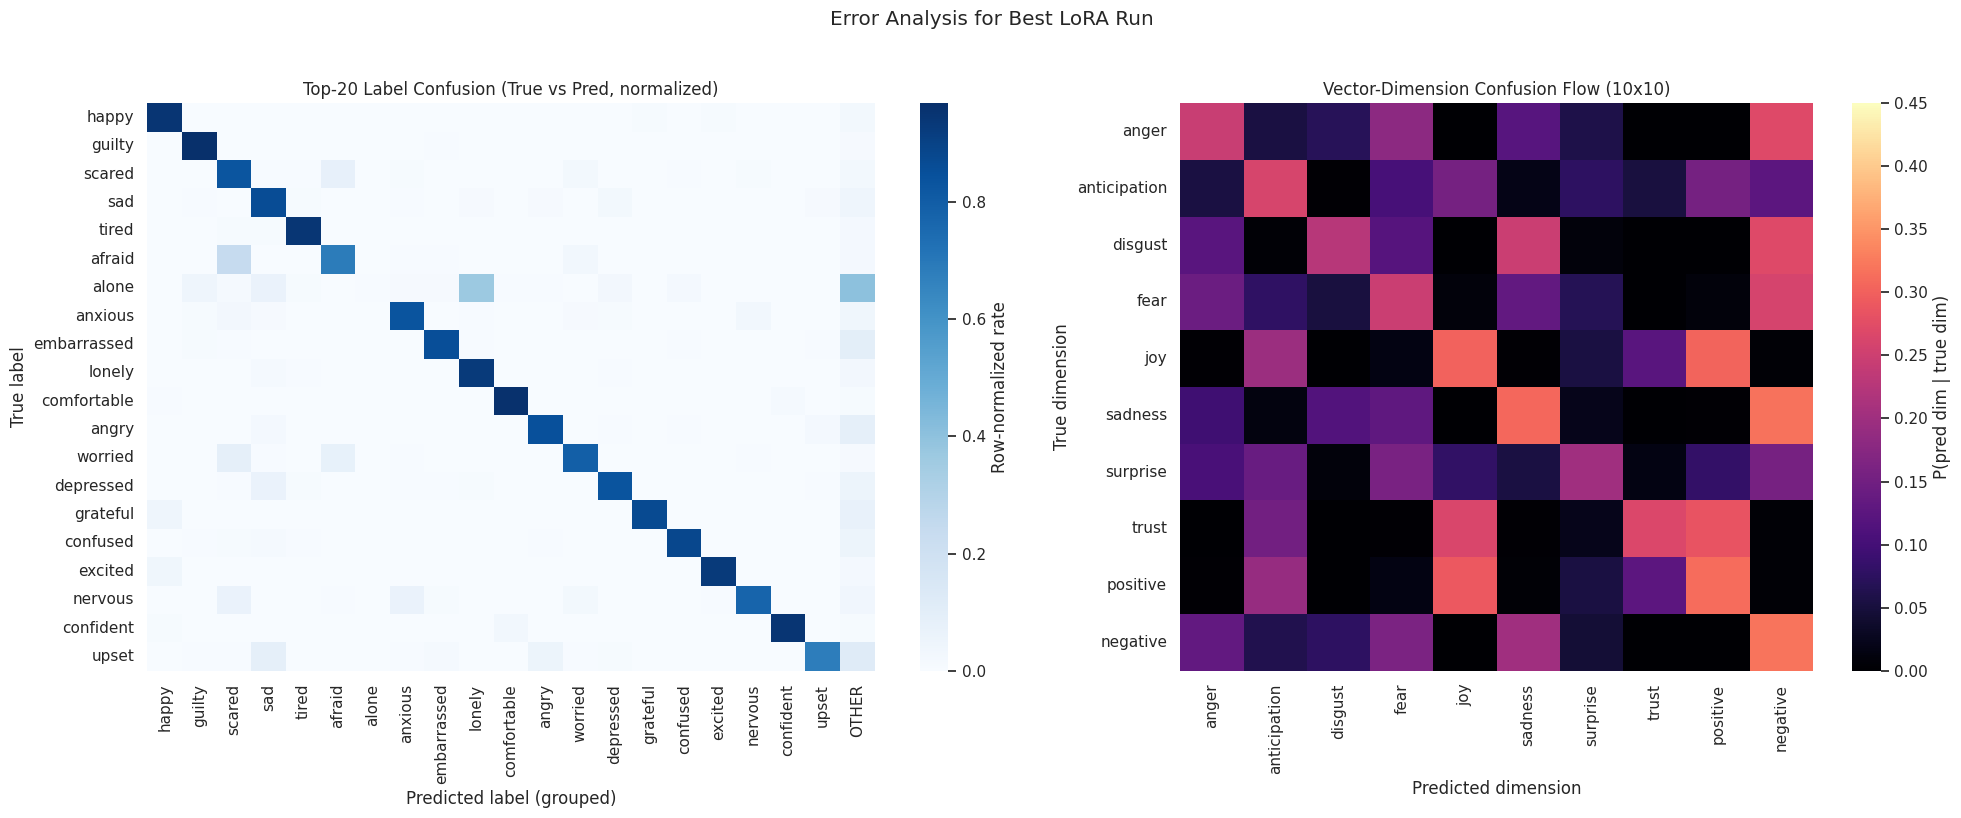

Parsed mask pairs: 55372
Empirical exact-vector accuracy from this file: 0.831431
Top true->pred label confusions:


,true,pred,count
113,alone,lonely,577
34,afraid,scared,407
2256,scared,afraid,220
2491,thankful,grateful,202
110,alone,isolated,198
775,disheartened,ail,166
2481,terrified,scared,142
107,alone,hopeless,137
126,alone,sad,102
2759,worried,scared,100


Weakest-preserved emotion dimensions (lower is worse):


,dimension,diag_preservation
6,surprise,0.201461
2,disgust,0.225632
0,anger,0.245669
3,fear,0.247132
1,anticipation,0.261125
7,trust,0.267073
4,joy,0.300924
5,sadness,0.306477
8,positive,0.311787
9,negative,0.318940


In [7]:
# Cell 5: Confusion analysis for best LoRA run (label-level + vector-dimension level).
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'lora_df' not in globals() or lora_df.empty:
    raise RuntimeError('Run Cell 0 first (metrics load).')
if 'lex_df' not in globals():
    raise RuntimeError('Run Cell 1 first (lexicon/vector map load).')

# Pick best LoRA row by AccV with a usable clean output CSV path.
cand = lora_df.copy()
cand['accv'] = pd.to_numeric(cand.get('accv'), errors='coerce')
cand = cand[cand.get('is_lora', False) == True]
cand = cand.dropna(subset=['accv', 'clean_output_path']).sort_values('accv', ascending=False)
if cand.empty:
    raise RuntimeError('No LoRA rows with clean_output_path found in metrics table.')

best_row = None
for _, r in cand.iterrows():
    p = Path(str(r['clean_output_path']))
    if p.exists():
        best_row = r
        break
if best_row is None:
    raise FileNotFoundError('No existing clean_output_path found for top LoRA rows.')

best_path = Path(str(best_row['clean_output_path']))
print('Using best run:', best_row.get('model_id', 'unknown'))
print('AccV:', float(best_row['accv']))
print('Clean output:', best_path)

cdf = pd.read_csv(best_path, usecols=['labels', 'output_formatted'])

# Robust list parser for CSV stringified lists.
def _parse_list(x):
    if isinstance(x, list):
        return [str(v).strip().lower() for v in x]
    if not isinstance(x, str):
        return None
    s = x.strip()
    if not s or s == 'INVALID OUTPUT':
        return None
    try:
        v = ast.literal_eval(s)
    except Exception:
        return None
    if not isinstance(v, list):
        return None
    return [str(i).strip().lower() for i in v]

true_tokens, pred_tokens = [], []
for t_raw, p_raw in zip(cdf['labels'].tolist(), cdf['output_formatted'].tolist()):
    t_list = _parse_list(t_raw)
    p_list = _parse_list(p_raw)
    if t_list is None or p_list is None:
        continue
    for t, p in zip(t_list, p_list):
        true_tokens.append(t)
        pred_tokens.append(p)

if not true_tokens:
    raise RuntimeError('No valid parsed label/prediction pairs found for confusion analysis.')

pairs_df = pd.DataFrame({'true': true_tokens, 'pred': pred_tokens})
error_df = pairs_df[pairs_df['true'] != pairs_df['pred']].copy()

# ---------- 1) Label-level confusion (top-K true labels) ----------
TOP_K = 20
top_true = pairs_df['true'].value_counts().head(TOP_K).index.tolist()
sub = pairs_df[pairs_df['true'].isin(top_true)].copy()
sub['pred_group'] = sub['pred'].where(sub['pred'].isin(top_true), 'OTHER')

cm = pd.crosstab(sub['true'], sub['pred_group'])
cm = cm.reindex(index=top_true, columns=top_true + ['OTHER'], fill_value=0)
cm_norm = cm.div(cm.sum(axis=1).replace(0, 1), axis=0)

# ---------- 2) Vector-dimension confusion flow ----------
# Dimension names come from lexicon columns after the word column.
vec_cols = [str(c) for c in lex_df.columns[1:]]
vec_map_local = {str(r['word']).lower(): np.array(r.iloc[1:].astype(int).tolist(), dtype=int) for _, r in lex_df.iterrows()}
zero_vec = np.zeros(len(vec_cols), dtype=int)

flow = np.zeros((len(vec_cols), len(vec_cols)), dtype=float)
exact_match = 0
for t, p in zip(true_tokens, pred_tokens):
    tv = vec_map_local.get(t, zero_vec)
    pv = vec_map_local.get(p, zero_vec)
    if np.array_equal(tv, pv):
        exact_match += 1
    t_idx = np.where(tv == 1)[0]
    p_idx = np.where(pv == 1)[0]
    if len(t_idx) == 0 or len(p_idx) == 0:
        continue
    for i in t_idx:
        for j in p_idx:
            flow[i, j] += 1

flow_df = pd.DataFrame(flow, index=vec_cols, columns=vec_cols)
flow_norm = flow_df.div(flow_df.sum(axis=1).replace(0, 1), axis=0)

# ---------- plots ----------
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1.15, 1.0]})

sns.heatmap(
    cm_norm,
    cmap='Blues',
    ax=axes[0],
    cbar_kws={'label': 'Row-normalized rate'},
    vmin=0,
    vmax=max(0.35, float(cm_norm.values.max()) if cm_norm.size else 0.35),
)
axes[0].set_title(f'Top-{TOP_K} Label Confusion (True vs Pred, normalized)')
axes[0].set_xlabel('Predicted label (grouped)')
axes[0].set_ylabel('True label')

sns.heatmap(
    flow_norm,
    cmap='magma',
    ax=axes[1],
    cbar_kws={'label': 'P(pred dim | true dim)'},
    vmin=0,
    vmax=max(0.45, float(flow_norm.values.max()) if flow_norm.size else 0.45),
)
axes[1].set_title('Vector-Dimension Confusion Flow (10x10)')
axes[1].set_xlabel('Predicted dimension')
axes[1].set_ylabel('True dimension')

fig.suptitle('Error Analysis for Best LoRA Run', y=1.02)
fig.tight_layout()
plt.show()

# ---------- summary tables ----------
accv_empirical = exact_match / len(true_tokens)
print(f'Parsed mask pairs: {len(true_tokens)}')
print(f'Empirical exact-vector accuracy from this file: {accv_empirical:.6f}')

if not error_df.empty:
    top_err = (
        error_df.groupby(['true', 'pred'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .head(30)
    )
    print('Top true->pred label confusions:')
    display(top_err)

# Per-dimension diagonal is "same-dimension preserved" probability under the flow view.
diag = pd.DataFrame({'dimension': vec_cols, 'diag_preservation': np.diag(flow_norm.values)})
diag = diag.sort_values('diag_preservation', ascending=True)
print('Weakest-preserved emotion dimensions (lower is worse):')
display(diag)

